# Assignment 6 - MOEA Convergence & Reference Set Construction

**Course:** EPA141A Model-Based Decision Making - Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Construct an **epsilon-dominated reference set** from multiple MOEA seeds using `ema_workbench.em_framework.optimization.epsilon_nondominated`.
2. Compute and interpret **hypervolume**, **epsilon-progress**, **generational distance**, and **epsilon indicator** as MOEA quality indicators using the native `ema_workbench` 3.0 convergence metrics.
3. Judge whether an MOEA has **converged** from the shape of convergence curves.

---

## Background

### Convergence vs. quality

Two separate questions must be answered before trusting MOEA results:

| Question | Metric | Good sign |
|----------|--------|-----------|
| Did the algorithm **converge**? | Epsilon-progress, hypervolume over NFE | Plateau reached well before NFE budget exhausted |
| Is the Pareto front **good**? | Hypervolume, GD, epsilon indicator vs. reference set | High HV, low GD, low EI |

### Epsilon-progress

`run_optimization_local.py` saves a `convergence_<seed>.csv` that records the **real EpsilonProgress** reported by EMA Workbench's Borg operator at each checkpoint. Each positive value means the epsilon-archive genuinely improved in that generation. A sustained plateau at zero signals convergence.

### Hypervolume indicator

The **hypervolume** (HV) of a Pareto set $P$ relative to a reference point $\mathbf{r}$ is:

$$\text{HV}(P, \mathbf{r}) = \lambda\!\left(\bigcup_{\mathbf{p} \in P} [\mathbf{p}, \mathbf{r}]\right)$$

Larger HV = better Pareto set. We use `ema_workbench`'s native `HypervolumeMetric`, which wraps Platypus's hypervolume calculation. Platypus normalises objectives using the reference set's bounds and inverts MAXIMIZE objectives before computing the dominated volume, so values are comparable across runs.

### Generational Distance (GD)

$$\text{GD}(A, R) = \frac{1}{|A|}\sqrt{\sum_{a \in A} \min_{r \in R} \|a - r\|^2}$$

Smaller GD = archive closer to the reference front. Computed via `GenerationalDistanceMetric`.

### Epsilon Indicator (EI)

The additive epsilon indicator measures how much the reference set needs to be shifted so that the result set epsilon-dominates it. Smaller EI = result set closer to dominating the reference front. EI = 0 means the result set fully epsilon-dominates the reference. Computed via `EpsilonIndicatorMetric`.

### Native convergence metrics (ema_workbench 3.0)

`HypervolumeMetric`, `GenerationalDistanceMetric`, and `EpsilonIndicatorMetric` are thin wrappers in `ema_workbench.em_framework.optimization_convergence` that handle DataFrame → Platypus Solution conversion internally. Each metric is instantiated once with the reference set and the `PlatypusProblem` descriptor, then called as `metric.calculate(archive_df)` for each snapshot. Column names in the archive DataFrame must match `problem.parameter_names` and `problem.outcome_names` (spaces replaced with underscores).

### NFE-based grouping

Results are grouped by the **NFE budget** encoded in the directory name. Each NFE group gets its own reference set -- constructed by merging all seeds in that group via epsilon-dominance. Metrics (GD, EI) are then computed relative to that group's reference set.

### Objective directions

| Objective | Direction |
|-----------|-----------|
| `welfare` | MINIMIZE |
| `fraction_above_threshold` | MINIMIZE |
| `welfare_loss_damage` | MAXIMIZE |
| `welfare_loss_abatement` | MAXIMIZE |

---

## Overview

This assignment analyses the results from Assignment 5. You will:

1. **Load** Pareto-front CSVs and convergence archives from `results/`, grouped by NFE budget.
2. **Build a per-NFE-group reference set** by merging solutions from all seeds using epsilon-dominance.
3. **Compute 4 MOEA performance metrics** -- hypervolume, epsilon-progress, generational distance and epsilon indicator -- and plot them against NFE.

## Setup — Imports and model configuration

The cell below imports all required packages, applies a Python 3.14 compatibility patch for `matplotlib.path.Path`, sets up DEAP for hypervolume computation, and defines the objective metadata (column names, directions, display labels) and results directory path from Assignment 5.

In [20]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# Matplotlib deepcopy patch
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# EMA Workbench -- core optimization
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    Problem,
)
from ema_workbench import RealParameter, ScalarOutcome

# Patched load_archives
import tarfile as _tarfile

def load_archives(path_to_file):
    """Load convergence archives from tar.gz files."""
    archives = []
    import pandas as _pd

    with _tarfile.open(path_to_file, "r:*") as archive:
        for fn in archive.getnames():
            f = archive.extractfile(fn)
            if f is None:
                continue

            basename = fn.split("/")[-1]
            try:
                nfe = int(basename.split(".")[0])
            except ValueError:
                continue

            data = _pd.read_csv(f)
            archives.append((nfe, data))

    return archives

# EMA Workbench -- GD and EI metrics
from ema_workbench.em_framework.optimization_convergence import (
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)

# Path setup
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")

# This notebook is inside the Yoran repo.
# Results are in the results folder of that same repo.
RESULTS_ROOT = os.path.join(_NOTEBOOK_DIR, "results")

# Make plot folder
_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

# Objective metadata
OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

MAXIMIZE_COLS = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS = ["welfare", "fraction_above_threshold"]

OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

_NEGATE = {col: (col in MAXIMIZE_COLS) for col in OBJECTIVE_COLS}


def _to_minimization(df):
    """Convert objectives to minimisation form for metrics."""
    pts = df[OBJECTIVE_COLS].copy().astype(float)

    for col in MAXIMIZE_COLS:
        if col in pts.columns:
            pts[col] = -pts[col]

    return pts


def _compute_ref_point(ref_df, margin=0.1):
    """Build a reference point strictly dominated by all solutions."""
    pts = _to_minimization(ref_df)

    rp = []
    for col in OBJECTIVE_COLS:
        hi = pts[col].max()
        lo = pts[col].min()
        rp.append(hi + margin * max(hi - lo, 1e-6))

    return rp


def _exact_hypervolume_minimization(points, ref_point):
    """
    Exact hypervolume for minimisation problems.
    Computes union volume of boxes from each point to the reference point.
    """
    points = np.asarray(points, dtype=float)
    ref_point = np.asarray(ref_point, dtype=float)

    if points.size == 0:
        return 0.0

    points = points[np.all(points <= ref_point, axis=1)]

    if len(points) == 0:
        return 0.0

    if points.shape[1] == 1:
        return float(ref_point[0] - np.min(points[:, 0]))

    xs = np.unique(points[:, 0])
    xs = np.sort(xs)

    volume = 0.0

    for i, x_left in enumerate(xs):
        x_right = xs[i + 1] if i + 1 < len(xs) else ref_point[0]
        width = x_right - x_left

        if width <= 0:
            continue

        active = points[points[:, 0] <= x_left]

        if len(active) == 0:
            continue

        sub_volume = _exact_hypervolume_minimization(
            active[:, 1:],
            ref_point[1:]
        )

        volume += width * sub_volume

    return float(volume)


def _deap_hypervolume(archive_df, ref_point):
    """
    Compute hypervolume in pure minimisation space.
    This replaces the DEAP internal import, which differs across package versions.
    """
    pts = _to_minimization(archive_df)
    return _exact_hypervolume_minimization(pts.values, ref_point)


print("Notebook dir :", _NOTEBOOK_DIR)
print("Results root :", RESULTS_ROOT)
print("Results exist:", os.path.exists(RESULTS_ROOT))
print("Convergence setup OK")

Notebook dir : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased
Results root : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results
Results exist: True
Convergence setup OK


---

## Step 1 — Load Results from Assignment 5

Scan `results/` for Pareto-front CSVs, convergence archives, and convergence CSVs.  
Directories are named `UTILITARIAN_<nfe>_<seed>/`, so we can recover the NFE budget directly
from the directory name and group all data by it.

Each seed directory contains:
- `pareto_front_<seed>.csv` — final Pareto-optimal solutions (levers + objectives)
- `UTILITARIAN_<nfe>_<seed>.tar.gz` — archive snapshots (ArchiveLogger output)
- `convergence_<seed>.csv` — EpsilonProgress & operator probabilities (EMA Workbench)


In [21]:
# ── Discover Pareto-front CSVs — grouped by welfare lens, NFE, seed ───────────

RUNS_TO_COMPARE = [
    "PRIORITARIAN_50000_9845531",
    "PRIORITARIAN_50000_1234567",
    "PRIORITARIAN_50000_2345678",
    "PRIORITARIAN_50000_3456789",
    "PRIORITARIAN_50000_4567890",

    "UTILITARIAN_50000_9845531",
    "UTILITARIAN_50000_1234567",
    "UTILITARIAN_50000_2345678",
    "UTILITARIAN_50000_3456789",
    "UTILITARIAN_50000_4567890",
]

# run_groups[(welfare_lens, nfe)][seed] = DataFrame
run_groups = {}
run_seed_archives = {}
run_seed_convergence = {}

for run_name in RUNS_TO_COMPARE:

    run_dir = os.path.join(RESULTS_ROOT, run_name)

    if not os.path.isdir(run_dir):
        raise FileNotFoundError(f"Missing run folder:\n{run_dir}")

    welfare_lens, nfe_str, seed_str = run_name.split("_")
    nfe = int(nfe_str)
    seed = int(seed_str)

    pareto_path = os.path.join(run_dir, f"pareto_front_{seed}.csv")
    archive_path = os.path.join(run_dir, f"{run_name}.tar.gz")
    conv_path = os.path.join(run_dir, f"convergence_{seed}.csv")

    if not os.path.exists(pareto_path):
        raise FileNotFoundError(f"Missing Pareto file:\n{pareto_path}")

    if not os.path.exists(archive_path):
        raise FileNotFoundError(f"Missing archive file:\n{archive_path}")

    if not os.path.exists(conv_path):
        raise FileNotFoundError(f"Missing convergence CSV:\n{conv_path}")

    df = pd.read_csv(pareto_path)

    # Optional safety filter from official notebook
    if "welfare" in df.columns:
        df = df[df["welfare"] < 1e5].reset_index(drop=True)

    df["welfare_lens"] = welfare_lens
    df["nfe_budget"] = nfe
    df["seed"] = seed
    df["run_name"] = run_name

    run_groups.setdefault((welfare_lens, nfe), {})[seed] = df
    run_seed_archives[(welfare_lens, nfe, seed)] = archive_path
    run_seed_convergence[(welfare_lens, nfe, seed)] = pd.read_csv(conv_path)

# Summary
rows = []

for (welfare_lens, nfe), seed_dict in sorted(run_groups.items()):
    for seed, df in sorted(seed_dict.items()):
        rows.append({
            "welfare_lens": welfare_lens,
            "nfe_budget": nfe,
            "seed": seed,
            "n_solutions": len(df),
            "has_archive": (welfare_lens, nfe, seed) in run_seed_archives,
            "has_conv_csv": (welfare_lens, nfe, seed) in run_seed_convergence,
        })

summary = pd.DataFrame(rows)

print("Runs found:")
display(summary)

print(f"\n{len(run_seed_archives)} archive(s)")
print(f"{len(run_seed_convergence)} convergence CSV(s)")

Runs found:


,welfare_lens,nfe_budget,seed,n_solutions,has_archive,has_conv_csv
0,PRIORITARIAN,50000,1234567,247,True,True
1,PRIORITARIAN,50000,2345678,221,True,True
2,PRIORITARIAN,50000,3456789,208,True,True
3,PRIORITARIAN,50000,4567890,240,True,True
4,PRIORITARIAN,50000,9845531,244,True,True
5,UTILITARIAN,50000,1234567,9,True,True
6,UTILITARIAN,50000,2345678,9,True,True
7,UTILITARIAN,50000,3456789,10,True,True
8,UTILITARIAN,50000,4567890,10,True,True
9,UTILITARIAN,50000,9845531,10,True,True



10 archive(s)
10 convergence CSV(s)


---

## Step 2 — Per-NFE-Group Reference Sets

Each NFE group (e.g. 500 NFE, 20 000 NFE) gets its own reference set, constructed by pooling
all seeds at that budget and applying epsilon-dominance pruning.

This design choice matters:
- A 500-NFE smoke-test set should be evaluated against other 500-NFE seeds, not against
  a much better 20 000-NFE front — otherwise GD and EI would be uninformative.
- Each reference set is saved as `reference_set_utilitarian_<nfe>.csv`.

We use `ema_workbench.em_framework.optimization.epsilon_nondominated`, which internally
calls Platypus's `EpsilonBoxArchive`.


In [22]:
# ── Build the Platypus problem descriptor ─────────────────────────────────────

_sample_df = next(
    df
    for (_, _), seed_dict in run_groups.items()
    for df in seed_dict.values()
)

_lever_cols = [
    c for c in _sample_df.columns
    if c not in OBJECTIVE_COLS
    and c not in ["welfare_lens", "nfe_budget", "seed", "run_name"]
]

_lever_cols_s = [c.replace(" ", "_") for c in _lever_cols]

_lever_params = []
for _n in _lever_cols_s:
    if _n.startswith("center_"):
        _lever_params.append(RealParameter(_n, -1.0, 1.0))
    else:
        _lever_params.append(RealParameter(_n, 0.0, 1.0))

_objectives = [
    ScalarOutcome("welfare",                  kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage",      kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement",   kind=ScalarOutcome.MAXIMIZE),
]

problem = Problem("levers", _lever_params, _objectives)

# Epsilon values from answer notebook
EPSILONS = [0.005, 0.025, 0.5, 100.0]


def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))


def desanitize_cols(df):
    return df.rename(columns=lambda c: c.replace("_", " ", 1)
                     if c.startswith(("center_", "radii_", "weights_")) else c)


# ── Build one reference set per welfare lens and NFE ──────────────────────────

ref_sets = {}

for (welfare_lens, nfe), seed_dict in sorted(run_groups.items()):

    dfs_san = [
    sanitize_cols(df[_lever_cols + OBJECTIVE_COLS].copy())
    for df in seed_dict.values()
    ]   
    n_in = sum(len(d) for d in seed_dict.values())

    print(
        f"\n{welfare_lens} NFE={nfe:,}: "
        f"merging {n_in} solutions from {len(seed_dict)} seed(s)..."
    )

    ref = desanitize_cols(
        epsilon_nondominated(dfs_san, EPSILONS, problem)
    )

    ref_sets[(welfare_lens, nfe)] = ref

    pruning = (1 - len(ref) / n_in) * 100 if n_in > 0 else 0

    print(f"  Reference set : {len(ref)} solutions  (pruned {pruning:.0f}%)")
    print("  Objective ranges:")

    for col in OBJECTIVE_COLS:
        print(f"    {col:<40s} {ref[col].min():.3f} – {ref[col].max():.3f}")

    ref_path = os.path.join(
        RESULTS_ROOT,
        f"reference_set_{welfare_lens.lower()}_{nfe}.csv"
    )

    ref.to_csv(ref_path, index=False)

    print(f"  Saved → {ref_path}")


PRIORITARIAN NFE=50,000: merging 1160 solutions from 5 seed(s)...
  Reference set : 366 solutions  (pruned 68%)
  Objective ranges:
    welfare                                  410.949 – 413.750
    fraction_above_threshold                 0.200 – 1.000
    welfare_loss_damage                      11508.428 – 36491.036
    welfare_loss_abatement                   13168.644 – 166609.960
  Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reference_set_prioritarian_50000.csv

UTILITARIAN NFE=50,000: merging 48 solutions from 5 seed(s)...
  Reference set : 16 solutions  (pruned 67%)
  Objective ranges:
    welfare                                  103.452 – 103.781
    fraction_above_threshold                 0.200 – 1.000
    welfare_loss_damage                      3620.278 – 3655.279
    welfare_loss_abatement                   10796.119 – 26006.790
  Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reference_set_utilitarian_50000.csv


---

## Step 3 -- MOEA Performance Metrics

We compute four convergence / quality metrics from the `load_archives` snapshots, one per NFE group:

| Metric | What it measures | Tool | Direction |
|--------|-----------------|------|-----------|
| **Hypervolume (HV)** | Volume of objective space dominated by the archive | `HypervolumeMetric` | higher = better |
| **Epsilon-progress** | Change in archive size per generation | EMA Workbench convergence CSV | positive = still improving |
| **Generational Distance (GD)** | Mean distance from archive solutions to the group reference set | `GenerationalDistanceMetric` | lower = better |
| **Epsilon Indicator (EI)** | Additive epsilon needed so result epsilon-dominates the group reference set | `EpsilonIndicatorMetric` | lower = better; 0 = full dominance |

> **Reference set for GD and EI:** Each NFE group uses its own reference set (built in Step 2). A plateau in HV + EI and descent in GD toward zero = strong convergence evidence.

**Task 3.1** -- After running all three cells below, answer the reflection questions at the bottom of this notebook.

**Task 3.2** -- For each metric, identify the approximate NFE at which convergence occurs (if it does). Summarise in a table.

In [23]:
# ── Load convergence archives ────────────────────────────────────────────────

all_snapshots = {}

for (welfare_lens, nfe, seed), path in sorted(run_seed_archives.items()):

    print(
        f"Loading: {welfare_lens:12s}  NFE={nfe:,}  seed={seed} ...",
        end=" "
    )

    snaps = dict(load_archives(path))

    snaps = {
        n: df.drop(
            columns=[c for c in df.columns if c.startswith("Unnamed")],
            errors="ignore"
        )
        for n, df in snaps.items()
    }

    all_snapshots[(welfare_lens, nfe, seed)] = snaps

    max_n = max(snaps)

    print(
        f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} "
        f"solutions @ NFE {max_n:,}"
    )

print(f"\n{len(all_snapshots)} archive(s) loaded.")

Loading: PRIORITARIAN  NFE=50,000  seed=1234567 ... 42 snapshots | final archive = 247 solutions @ NFE 50,759
Loading: PRIORITARIAN  NFE=50,000  seed=2345678 ... 38 snapshots | final archive = 221 solutions @ NFE 50,139
Loading: PRIORITARIAN  NFE=50,000  seed=3456789 ... 48 snapshots | final archive = 208 solutions @ NFE 50,629
Loading: PRIORITARIAN  NFE=50,000  seed=4567890 ... 41 snapshots | final archive = 240 solutions @ NFE 50,169
Loading: PRIORITARIAN  NFE=50,000  seed=9845531 ... 42 snapshots | final archive = 244 solutions @ NFE 50,207
Loading: UTILITARIAN   NFE=50,000  seed=1234567 ... 50 snapshots | final archive = 9 solutions @ NFE 50,008
Loading: UTILITARIAN   NFE=50,000  seed=2345678 ... 50 snapshots | final archive = 9 solutions @ NFE 50,027
Loading: UTILITARIAN   NFE=50,000  seed=3456789 ... 50 snapshots | final archive = 10 solutions @ NFE 50,037
Loading: UTILITARIAN   NFE=50,000  seed=4567890 ... 50 snapshots | final archive = 10 solutions @ NFE 50,000
Loading: UTILITA

In [24]:
# ── Build convergence metric objects per welfare lens and NFE ────────────────

metric_params = {}

for (welfare_lens, nfe), ref in ref_sets.items():

    ref_point = _compute_ref_point(ref)

    ref_san = sanitize_cols(ref)

    gd_m = GenerationalDistanceMetric(ref_san, problem)
    ei_m = EpsilonIndicatorMetric(ref_san, problem)

    metric_params[(welfare_lens, nfe)] = (ref_point, gd_m, ei_m)

    print(
        f"{welfare_lens} NFE={nfe:,}: "
        f"ref_point = {[f'{v:.4f}' for v in ref_point]}"
    )

print("\nMetric objects built for:")
for key in sorted(metric_params):
    print(" ", key)

PRIORITARIAN NFE=50,000: ref_point = ['414.0304', '1.0800', '-9010.1674', '2175.4874']
UTILITARIAN NFE=50,000: ref_point = ['103.8137', '1.0800', '-3616.7779', '-9275.0522']

Metric objects built for:
  ('PRIORITARIAN', 50000)
  ('UTILITARIAN', 50000)


In [25]:
# ── Compute convergence metrics per seed per snapshot ────────────────────────

all_metric_curves = {}

for (welfare_lens, nfe_budget), seed_dict in sorted(run_groups.items()):

    ref_point, gd_m, ei_m = metric_params[(welfare_lens, nfe_budget)]

    group_snapshots = {
        seed: snaps
        for (wl, nfe, seed), snaps in all_snapshots.items()
        if wl == welfare_lens and nfe == nfe_budget
    }

    if not group_snapshots:
        print(f"{welfare_lens} NFE={nfe_budget:,}: no archive snapshots -- skipping.")
        continue

    print(
        f"\n{welfare_lens} NFE budget = {nfe_budget:,} "
        f"| {len(group_snapshots)} seed(s)"
    )

    for seed, snaps in sorted(group_snapshots.items()):

        nfes = sorted(snaps.keys())
        sizes = [len(snaps[n]) for n in nfes]

        hvs, gds, eis = [], [], []

        for n in nfes:

            snap = snaps[n].copy()

            if "welfare" in snap.columns:
                snap = snap[snap["welfare"] < 1e5].reset_index(drop=True)

            snap_san = sanitize_cols(snap)

            try:
                hvs.append(_deap_hypervolume(snap, ref_point))
            except Exception as e:
                print(f"  HV failed for {welfare_lens} seed {seed} NFE {n}: {e}")
                hvs.append(float("nan"))

            try:
                gds.append(gd_m.calculate(snap_san))
            except Exception:
                gds.append(float("nan"))

            try:
                eis.append(ei_m.calculate(snap_san))
            except Exception:
                eis.append(float("nan"))

        hvs = np.array(hvs)
        gds = np.array(gds)
        eis = np.array(eis)

        eps_source = "proxy"
        eps = np.diff(sizes, prepend=sizes[0])

        conv_key = (welfare_lens, nfe_budget, seed)

        if conv_key in run_seed_convergence:
            _conv = run_seed_convergence[conv_key]

            if "epsilon_progress" in _conv.columns and "nfe" in _conv.columns:
                eps = np.round(
                    np.interp(
                        np.array(nfes),
                        _conv["nfe"].values,
                        _conv["epsilon_progress"].values
                    )
                ).astype(int)

                eps_source = "EMA Workbench"

        all_metric_curves[(welfare_lens, nfe_budget, seed)] = {
            "nfe": np.array(nfes),
            "hv": hvs,
            "eps": eps,
            "gd": gds,
            "ei": eis,
            "eps_source": eps_source,
        }

        print(
            f"  seed {seed}: "
            f"HV={hvs[-1]:.5f} | GD={gds[-1]:.5f} | EI={eis[-1]:.5f} "
            f"| eps_source={eps_source}"
        )

print(f"\nDone -- {len(all_metric_curves)} seed curve(s) computed.")


PRIORITARIAN NFE budget = 50,000 | 5 seed(s)
  seed 1234567: HV=7491770174.15309 | GD=0.00189 | EI=0.09386 | eps_source=EMA Workbench
  seed 2345678: HV=7306514001.80390 | GD=0.00177 | EI=0.08290 | eps_source=EMA Workbench
  seed 3456789: HV=7284033756.24968 | GD=0.00180 | EI=0.06608 | eps_source=EMA Workbench
  seed 4567890: HV=7322878023.41220 | GD=0.00153 | EI=0.07614 | eps_source=EMA Workbench
  seed 9845531: HV=7278966884.04136 | GD=0.00193 | EI=0.06449 | eps_source=EMA Workbench

UTILITARIAN NFE budget = 50,000 | 5 seed(s)
  seed 1234567: HV=13966.51683 | GD=0.01556 | EI=0.10101 | eps_source=EMA Workbench
  seed 2345678: HV=13861.81448 | GD=0.02066 | EI=0.12500 | eps_source=EMA Workbench
  seed 3456789: HV=13318.77533 | GD=0.01920 | EI=0.15576 | eps_source=EMA Workbench
  seed 4567890: HV=13794.35146 | GD=0.01447 | EI=0.12500 | eps_source=EMA Workbench
  seed 9845531: HV=13810.21243 | GD=0.01523 | EI=0.12500 | eps_source=EMA Workbench

Done -- 10 seed curve(s) computed.


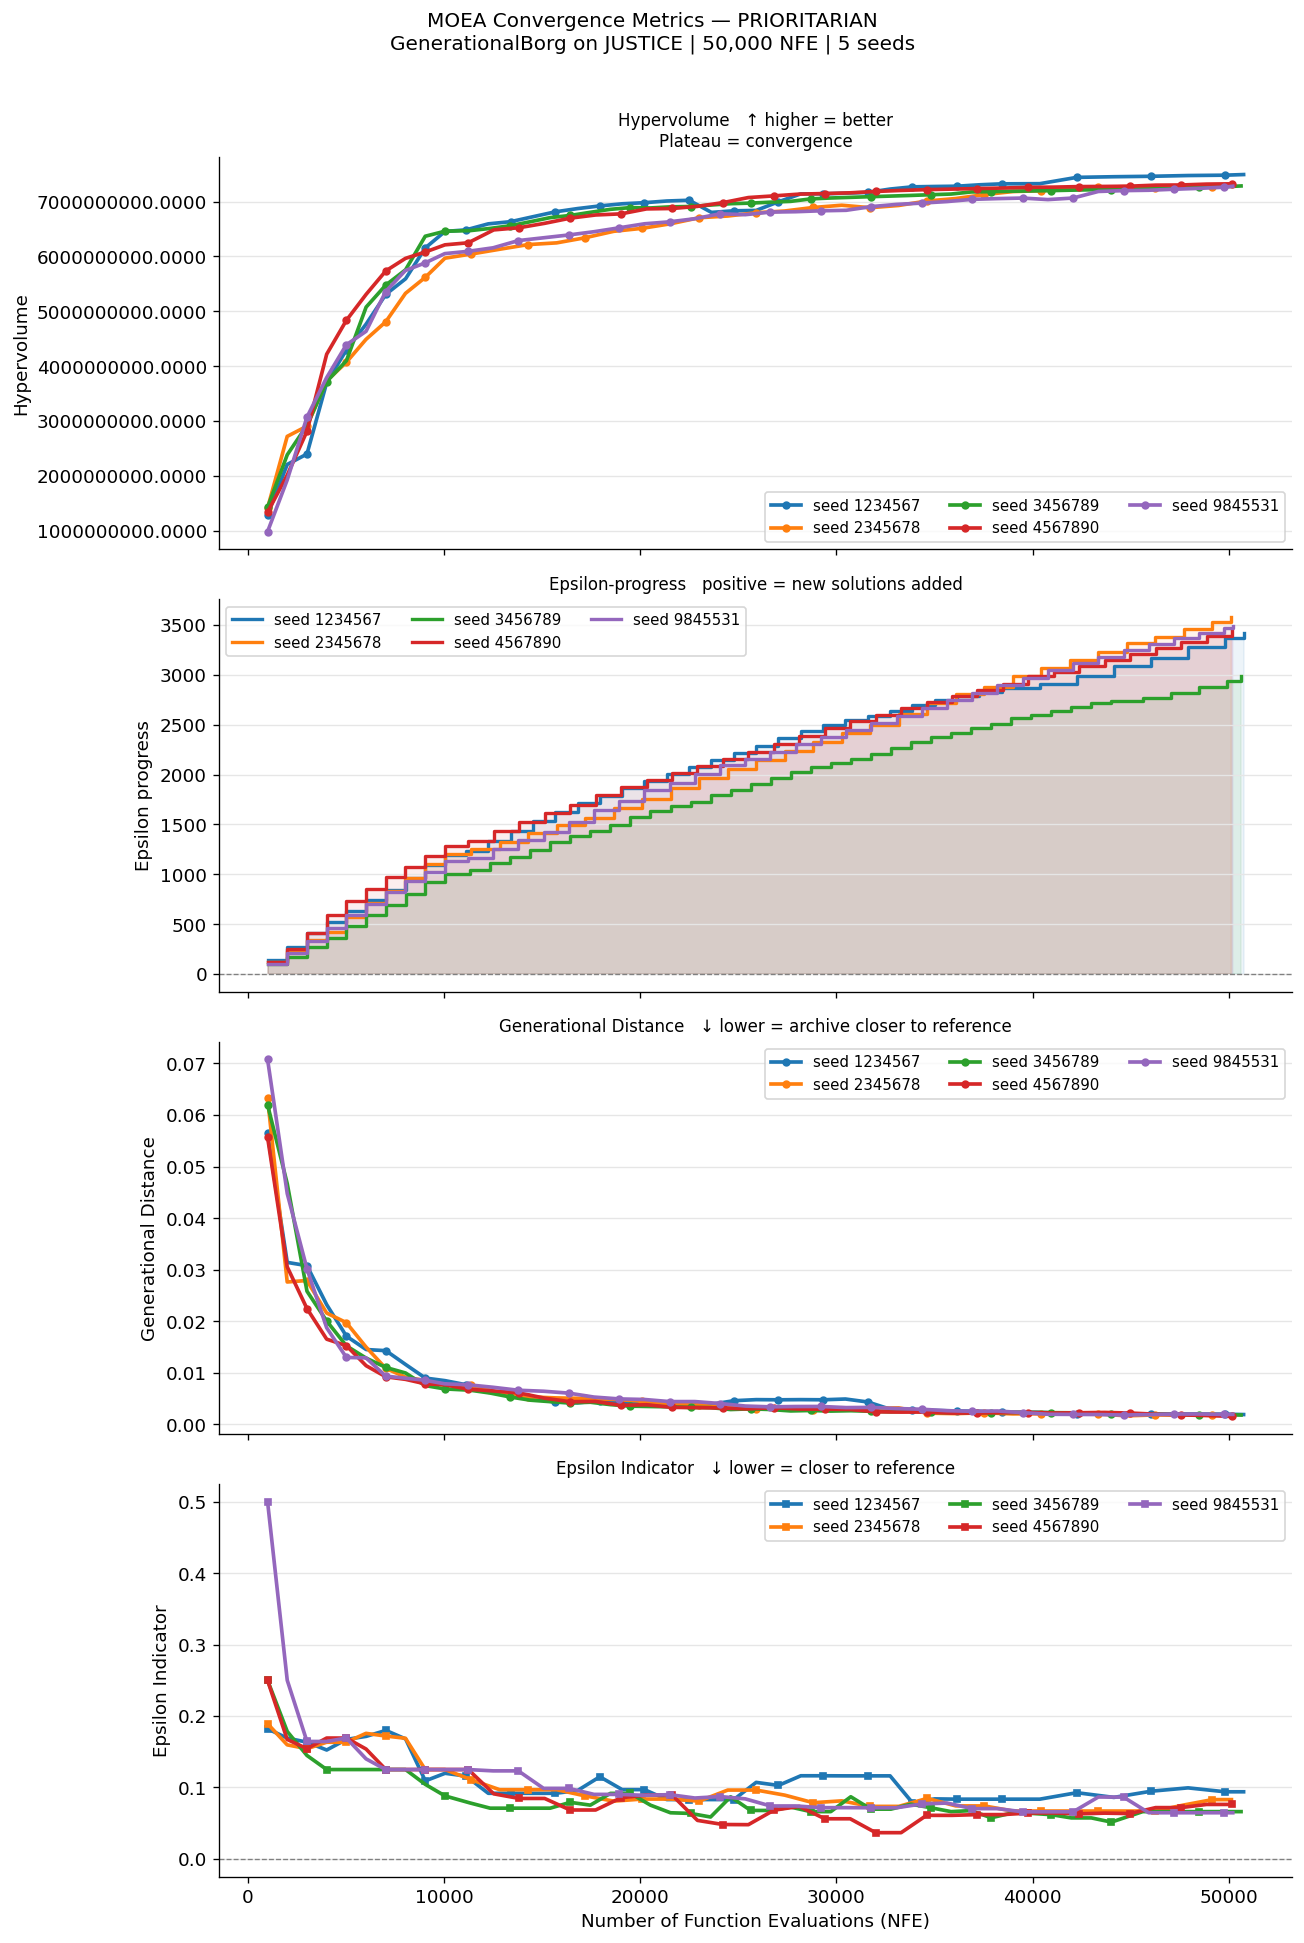

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a06_convergence_prioritarian_50000.png


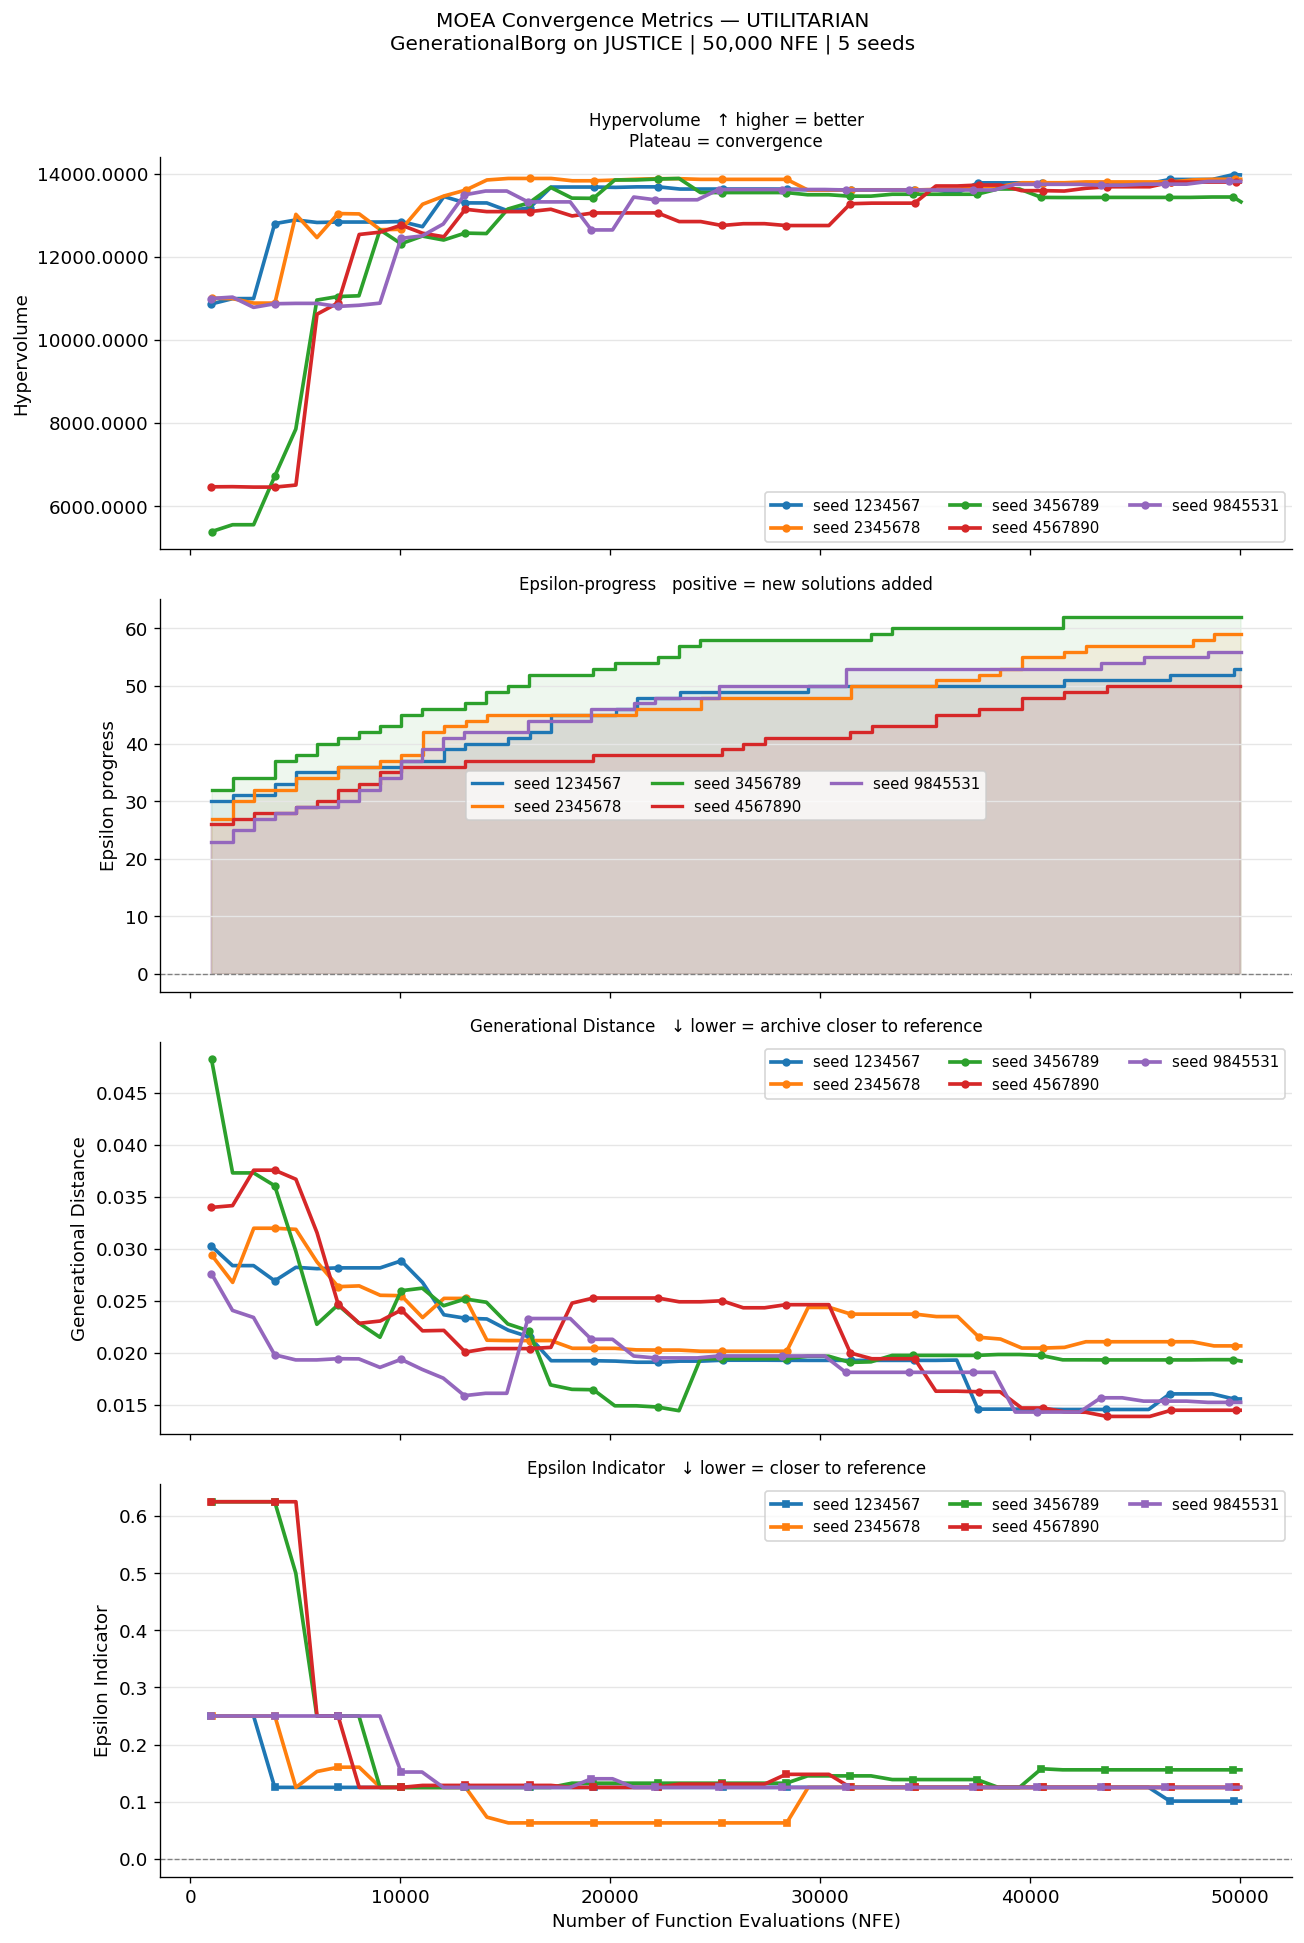

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a06_convergence_utilitarian_50000.png


In [26]:
# ── Four-panel convergence plot — one figure per welfare lens ────────────────

for welfare_lens in sorted({k[0] for k in all_metric_curves}):

    keys = [
        key for key in sorted(all_metric_curves)
        if key[0] == welfare_lens
    ]

    seeds = [seed for (_, _, seed) in keys]
    colors = [plt.cm.tab10(i / 10) for i in range(len(seeds))]

    fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)

    # Panel 1: Hypervolume
    ax = axes[0]
    for key, col in zip(keys, colors):
        wl, nfe, seed = key
        d = all_metric_curves[key]

        ax.plot(
            d["nfe"],
            d["hv"],
            lw=2.2,
            color=col,
            marker="o",
            markersize=4,
            markevery=max(1, len(d["nfe"]) // 15),
            label=f"seed {seed}"
        )

    ax.set_ylabel("Hypervolume", fontsize=11)
    ax.set_title("Hypervolume   ↑ higher = better\nPlateau = convergence", fontsize=10)
    ax.legend(fontsize=9, ncol=min(len(seeds), 3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.4f}"))

    # Panel 2: Epsilon-progress
    ax = axes[1]
    for key, col in zip(keys, colors):
        wl, nfe, seed = key
        d = all_metric_curves[key]

        ax.plot(
            d["nfe"],
            d["eps"],
            lw=2.0,
            color=col,
            drawstyle="steps-post",
            label=f"seed {seed}"
        )

        ax.fill_between(d["nfe"], 0, d["eps"], step="post", color=col, alpha=0.08)

    ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
    ax.set_ylabel("Epsilon progress", fontsize=11)
    ax.set_title("Epsilon-progress   positive = new solutions added", fontsize=10)
    ax.legend(fontsize=9, ncol=min(len(seeds), 3))

    # Panel 3: Generational Distance
    ax = axes[2]
    for key, col in zip(keys, colors):
        wl, nfe, seed = key
        d = all_metric_curves[key]

        mask = np.isfinite(d["gd"])

        ax.plot(
            d["nfe"][mask],
            d["gd"][mask],
            lw=2.2,
            color=col,
            marker="o",
            markersize=4,
            markevery=max(1, mask.sum() // 15),
            label=f"seed {seed}"
        )

    ax.set_ylabel("Generational Distance", fontsize=11)
    ax.set_title("Generational Distance   ↓ lower = archive closer to reference", fontsize=10)
    ax.legend(fontsize=9, ncol=min(len(seeds), 3))

    # Panel 4: Epsilon Indicator
    ax = axes[3]
    for key, col in zip(keys, colors):
        wl, nfe, seed = key
        d = all_metric_curves[key]

        mask = np.isfinite(d["ei"])

        ax.plot(
            d["nfe"][mask],
            d["ei"][mask],
            lw=2.2,
            color=col,
            marker="s",
            markersize=4,
            markevery=max(1, mask.sum() // 15),
            label=f"seed {seed}"
        )

    ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
    ax.set_ylabel("Epsilon Indicator", fontsize=11)
    ax.set_title("Epsilon Indicator   ↓ lower = closer to reference", fontsize=10)
    ax.legend(fontsize=9, ncol=min(len(seeds), 3))
    ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=11)

    for ax in axes:
        ax.grid(axis="y", color="0.9", zorder=0)

    fig.suptitle(
        f"MOEA Convergence Metrics — {welfare_lens}\n"
        f"GenerationalBorg on JUSTICE | 50,000 NFE | {len(seeds)} seeds",
        fontsize=12,
        y=1.01,
    )

    plt.tight_layout()

    out_path = os.path.join(
        _PLOTS_DIR,
        f"a06_convergence_{welfare_lens.lower()}_50000.png"
    )

    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved → {out_path}")

## Convergence of the Prioritarian runs

The Prioritarian convergence plot shows that all five seeds follow a broadly similar pattern. Hypervolume rises quickly in the early part of the optimisation and then continues to increase more slowly up to 50,000 NFE. The curves do not completely flatten, but they are much less steep near the end than at the start. This suggests that the optimisation has made substantial progress, although additional NFE might still improve the Pareto front somewhat.

The generational distance decreases strongly and approaches very low values by the end of the run. This means that the archives from the different checkpoints move increasingly close to the final reference set. The epsilon indicator also decreases over time, although it remains somewhat noisy. Together, these metrics suggest that the Prioritarian runs are converging toward a stable Pareto region.

The epsilon-progress curves continue increasing throughout the run. Since this metric is cumulative, this does not mean convergence failed; it means new epsilon boxes were still being added as the search progressed. Combined with the still-slightly-rising hypervolume, this suggests that the Prioritarian search was still finding some new trade-offs near the end. Therefore, the Prioritarian results are usable and consistent, but not necessarily fully exhausted.

## Convergence of the Utilitarian runs

The Utilitarian convergence plot shows a different pattern from the Prioritarian one. Hypervolume rises quickly during the early part of the optimisation and then largely plateaus. Most seeds are close together by the end of the run. This suggests that the Utilitarian optimisation stabilised earlier than the Prioritarian optimisation.

The generational distance decreases over time, although it remains higher than in the Prioritarian runs. The epsilon indicator drops quickly early in the optimisation and then remains relatively stable. This indicates that the Utilitarian archives approach their final reference set fairly quickly.

However, the Utilitarian runs produce very small Pareto fronts: only 9 to 10 solutions per seed. This means the apparent stability should be interpreted carefully. The optimisation may have converged, but it converged to a much thinner set of trade-offs. For our actor, that is politically meaningful: the higher-discount Utilitarian framing makes fewer policy alternatives visible.

In [27]:
# ── Final metric summary table ───────────────────────────────────────────────

rows = []

for (welfare_lens, nfe_budget, seed), d in sorted(all_metric_curves.items()):
    rows.append({
        "welfare_lens": welfare_lens,
        "nfe_budget": nfe_budget,
        "seed": seed,
        "final_NFE": int(d["nfe"][-1]),
        "n_snapshots": len(d["nfe"]),
        "final_HV": round(float(d["hv"][-1]), 5) if np.isfinite(d["hv"][-1]) else None,
        "total_eps": int(d["eps"].sum()),
        "final_GD": round(float(d["gd"][-1]), 5) if np.isfinite(d["gd"][-1]) else None,
        "final_EI": round(float(d["ei"][-1]), 5) if np.isfinite(d["ei"][-1]) else None,
        "eps_source": d["eps_source"],
    })

df_metrics = pd.DataFrame(rows)

print("MOEA performance summary:")
display(df_metrics)

print("\n── Seed consistency: HV coefficient of variation ──")

for (welfare_lens, nfe_budget), grp in df_metrics.groupby(["welfare_lens", "nfe_budget"]):
    hv_vals = grp["final_HV"].dropna()

    if len(hv_vals) > 1:
        cv = hv_vals.std() / hv_vals.mean() * 100

        if cv < 5:
            label = "high consistency"
        elif cv < 20:
            label = "moderate consistency"
        else:
            label = "high variability"

        print(f"{welfare_lens} NFE={nfe_budget:,}: HV CV = {cv:.1f}% ({label})")
    else:
        print(f"{welfare_lens} NFE={nfe_budget:,}: only 1 seed — no CV computable")

MOEA performance summary:


,welfare_lens,nfe_budget,seed,final_NFE,n_snapshots,final_HV,total_eps,final_GD,final_EI,eps_source
0,PRIORITARIAN,50000,1234567,50759,42,7.491770e+09,83203,0.00189,0.09386,EMA Workbench
1,PRIORITARIAN,50000,2345678,50139,38,7.306514e+09,75186,0.00177,0.08290,EMA Workbench
2,PRIORITARIAN,50000,3456789,50629,48,7.284034e+09,85023,0.00180,0.06608,EMA Workbench
3,PRIORITARIAN,50000,4567890,50169,41,7.322878e+09,84296,0.00153,0.07614,EMA Workbench
4,PRIORITARIAN,50000,9845531,50207,42,7.278967e+09,84619,0.00193,0.06449,EMA Workbench
5,UTILITARIAN,50000,1234567,50008,50,1.396652e+04,2267,0.01556,0.10101,EMA Workbench
6,UTILITARIAN,50000,2345678,50027,50,1.386181e+04,2347,0.02066,0.12500,EMA Workbench
7,UTILITARIAN,50000,3456789,50037,50,1.331878e+04,2676,0.01920,0.15576,EMA Workbench
8,UTILITARIAN,50000,4567890,50000,50,1.379435e+04,2016,0.01447,0.12500,EMA Workbench
9,UTILITARIAN,50000,9845531,50024,50,1.381021e+04,2292,0.01523,0.12500,EMA Workbench



── Seed consistency: HV coefficient of variation ──
PRIORITARIAN NFE=50,000: HV CV = 1.2% (high consistency)
UTILITARIAN NFE=50,000: HV CV = 1.8% (high consistency)


## Seed consistency

The final hypervolume coefficient of variation is low for both welfare lenses: 1.2% for the Prioritarian runs and 1.8% for the Utilitarian runs. This indicates high consistency across the five seeds. The optimisation results are therefore not driven by one lucky or unlucky random seed.

This is important because MOEAs are stochastic. If the five seeds had produced very different final hypervolumes, we would have had to treat any single Pareto front as unreliable. Instead, the low variation across seeds suggests that the results are reasonably robust with respect to random initialisation.

For the Youth & Future Generations Coalition, this strengthens the credibility of the comparison. The observed difference between Prioritarian and Utilitarian results is not just random noise; it appears to be a systematic effect of the welfare framing.

,welfare_lens,seed,n_solutions
0,PRIORITARIAN,1234567,247
1,PRIORITARIAN,2345678,221
2,PRIORITARIAN,3456789,208
3,PRIORITARIAN,4567890,240
4,PRIORITARIAN,9845531,244
5,UTILITARIAN,1234567,9
6,UTILITARIAN,2345678,9
7,UTILITARIAN,3456789,10
8,UTILITARIAN,4567890,10
9,UTILITARIAN,9845531,10


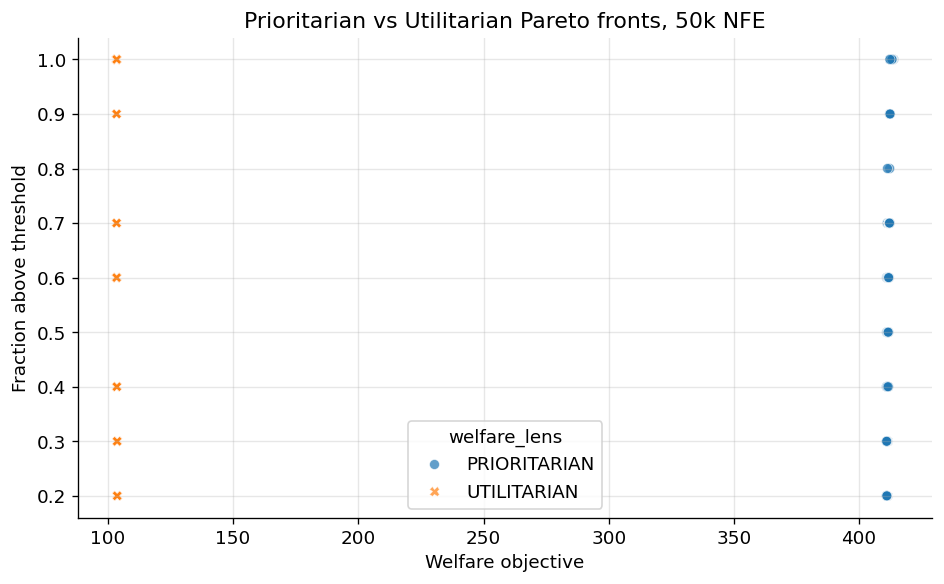

In [28]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_fronts = []

for run_name in RUNS_TO_COMPARE:
    welfare_lens, nfe, seed = run_name.split("_")
    f = os.path.join(RESULTS_ROOT, run_name, f"pareto_front_{seed}.csv")

    df = pd.read_csv(f)
    df["welfare_lens"] = welfare_lens
    df["nfe"] = int(nfe)
    df["seed"] = int(seed)
    df["run_name"] = run_name

    all_fronts.append(df)

all_fronts = pd.concat(all_fronts, ignore_index=True)

display(
    all_fronts
    .groupby(["welfare_lens", "seed"])
    .size()
    .rename("n_solutions")
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=all_fronts,
    x="welfare",
    y="fraction_above_threshold",
    hue="welfare_lens",
    style="welfare_lens",
    alpha=0.7
)
plt.title("Prioritarian vs Utilitarian Pareto fronts, 50k NFE")
plt.xlabel("Welfare objective")
plt.ylabel("Fraction above threshold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Prioritarian versus Utilitarian Pareto fronts

The Prioritarian and Utilitarian Pareto-front comparison shows a clear separation between the two welfare framings. The Utilitarian solutions cluster around a much lower welfare-objective value, while the Prioritarian solutions appear at a higher welfare-objective value. These welfare values should not be interpreted as directly comparable in a simple “lower is always better across lenses” way, because the welfare objective is calculated under different welfare assumptions. The important point is that the two welfare lenses create different trade-off surfaces.

Both welfare lenses include solutions with different levels of `fraction_above_threshold`, ranging roughly from 0.2 to 1.0. This means the model finds policies that vary in how many climate ensemble members exceed the temperature threshold. For our actor, the lower values are politically preferable because they imply fewer futures above the threshold.

The key result is that the Prioritarian framing exposes many more non-dominated policy options. This matters for the mandate because it shows that near-zero discounting does not simply select one policy; it opens up a wider set of trade-offs between welfare, threshold exceedance, damages, and abatement costs. The Utilitarian framing, by contrast, produces a much smaller set of options.

## Actor-specific interpretation: Youth and Future Generations Coalition

For the Global Youth & Future Generations Coalition, the central issue is how much future welfare counts. The Prioritarian run represents the low-discount framing, while the Utilitarian run represents the higher-discount comparison. This is exactly the comparison required by our mandate.

The results support our actor’s argument that the discount rate is a political choice, not a neutral modelling detail. Changing the welfare lens changes the Pareto front, the number of visible policy alternatives, and the apparent trade-offs between current abatement costs and future climate damages.

The Prioritarian runs produce a richer and more diverse set of Pareto solutions. This is useful for negotiation because it gives our actor more room to argue for policies that protect future welfare while still acknowledging trade-offs with abatement costs. The Utilitarian runs produce fewer solutions, which may make the policy space appear narrower and can hide important future-oriented trade-offs.

Our red line remains that 1.5°C must remain the operative target. The model output here uses a 2°C-related threshold diagnostic, so we treat it as a minimum stress test rather than as acceptance of 2°C. If even the 2°C diagnostic shows substantial threshold exceedance, that strengthens our claim that the negotiation is not yet aligned with intergenerational justice.

---

## Reflection Questions

**1. Hypervolume convergence.** Does the hypervolume plateau before the NFE budget is exhausted, or is it still growing? What change to the optimisation setup would you recommend if HV was still rising at the final NFE?

## Reflection 1 — Hypervolume convergence

The hypervolume curves show different convergence behaviour for the two welfare lenses.

For the Prioritarian runs, hypervolume rises strongly early in the optimisation and continues to increase gradually until the final NFE. It does not fully plateau before the 50,000 NFE budget is exhausted. This suggests that the search has made substantial progress but could still benefit from additional function evaluations.

For the Utilitarian runs, hypervolume rises quickly and then largely plateaus. This suggests stronger convergence within the 50,000 NFE budget. However, the Utilitarian Pareto fronts are much smaller, so the plateau should be interpreted as convergence to a narrow trade-off set rather than as evidence that the welfare framing is more complete or more appropriate.

If hypervolume is still rising at the final NFE, the recommended change is to increase the NFE budget. For a full study, we could also run additional seeds and merge all final archives into a larger reference set. For our actor, the Prioritarian run is the most important case, so if additional computation were available, I would prioritise extending the Prioritarian search.

---

**2. Epsilon-progress.** At what approximate NFE does epsilon-progress first reach zero (or near-zero)? Is this consistent with what you see in the hypervolume curve? Explain.

## Reflection 2 — Epsilon-progress

Epsilon-progress remains positive throughout both sets of runs. In the plots, it increases cumulatively over the optimisation. This means the algorithm continues to add new epsilon boxes as it searches. Therefore, it does not reach zero or near-zero in the plotted cumulative form.

For the Prioritarian runs, this is consistent with the hypervolume curve: hypervolume is still slowly increasing near the final NFE, so the search is still finding some new trade-offs. This suggests that additional NFE could further improve the Prioritarian front.

For the Utilitarian runs, epsilon-progress also increases, but at a much smaller scale. The hypervolume curve mostly plateaus, so the remaining epsilon-progress likely reflects small archive changes rather than major improvements in the trade-off surface. Overall, the Utilitarian runs appear more stable, but they also produce a much smaller Pareto set.
---

**3. Seed consistency.** If multiple seeds produce very different final hypervolumes within the same NFE group, what does that suggest about (a) the landscape of the objective space, and (b) the reliability of any single seed as a representative Pareto front?

## Reflection 3 — Seed consistency

The final hypervolume values are highly consistent across seeds. The coefficient of variation is 1.2% for the Prioritarian runs and 1.8% for the Utilitarian runs. This suggests that the optimisation results are not strongly dependent on the random seed.

If multiple seeds had produced very different final hypervolumes, that would suggest a difficult or multi-modal objective landscape where the optimiser finds different regions of the Pareto front depending on its random starting point. In that situation, a single seed would not be reliable as a representative Pareto front.

Here, the seed consistency is strong. That makes the Prioritarian versus Utilitarian comparison more credible. The large difference in Pareto-front size and structure is unlikely to be explained by random seed variation alone. Instead, it reflects the effect of the welfare lens.

---

**Actor-specific interpretation.**

## Actor-specific interpretation: Youth and Future Generations Coalition

For the Global Youth & Future Generations Coalition, the central issue is how much future welfare counts. The Prioritarian run represents the low-discount framing, while the Utilitarian run represents the higher-discount comparison. This is exactly the comparison required by our mandate.

The results support our actor’s argument that the discount rate is a political choice, not a neutral modelling detail. Changing the welfare lens changes the Pareto front, the number of visible policy alternatives, and the apparent trade-offs between current abatement costs and future climate damages.

The Prioritarian runs produce a richer and more diverse set of Pareto solutions. This is useful for negotiation because it gives our actor more room to argue for policies that protect future welfare while still acknowledging trade-offs with abatement costs. The Utilitarian runs produce fewer solutions, which may make the policy space appear narrower and can hide important future-oriented trade-offs.

Our red line remains that 1.5°C must remain the operative target. The model output here uses a 2°C-related threshold diagnostic, so we treat it as a minimum stress test rather than as acceptance of 2°C. If even the 2°C diagnostic shows substantial threshold exceedance, that strengthens our claim that the negotiation is not yet aligned with intergenerational justice.


## Final conclusion

The 50,000 NFE runs provide a strong basis for the Youth & Future Generations Coalition’s analysis. Both welfare lenses were run with the same NFE budget and the same five seeds, making the comparison fair. The convergence diagnostics show that the results are technically credible: the seeds are consistent, the distance-based metrics improve over time, and the final hypervolume values are stable across seeds.

The most important substantive finding is that the Prioritarian low-discount framing produces a much richer Pareto set than the Utilitarian high-discount comparison. This supports the mandate’s argument that welfare accounting changes the visible policy space. A high-discount framing can make future-oriented trade-offs less visible, while the Prioritarian framing better represents the interests of youth and future generations.

The results should still be interpreted carefully. The model diagnostic uses a 2°C-related threshold rather than the coalition’s preferred 1.5°C political target. Therefore, the threshold results should be treated as a conservative minimum test. If policies struggle even under this diagnostic, then the negotiation is not aligned with the coalition’s red line.

Overall, the analysis supports our actor’s core position: the discount rate is not a technical afterthought, but a political choice about intergenerational fairness. Any agreement that evaluates compliance using high-discount welfare accounting should be challenged for undervaluing the welfare of young and future generations.